In [81]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from arch import arch_model
from scipy.stats import rankdata

%matplotlib inline

step 1: implement volatility model (modified GARCH)  
  
$\sigma_{n}^{2} = \gamma V_{lt} +\alpha u_{n-1}^{2} + \beta\sigma_{n-1}^{2}$  
  
where:  
  
$\sigma_{n}$ is the volatility of the market variable for day $n$ (made at the end of day $n-1$). $\sigma_{n}^{2}$ is the variance of the market variable for day $n$  
$\gamma$ is the weight assigned to $V_{lt}$  
$V_{lt}$ is the long-run average variance rate  
$\alpha$ is the weight assigned to $u_{n-1}^{2}$   
$u_{n-1}$ is the percentage change in the market variable between the end of day $n-2$ and the end of day $n-1$ (the most recent daily percentage change in the market variable). $u_{n-1}^{2}$ is the squared return of the market variable between the end of day $n-2$ and the end of day $n-1$  

$u_{n-1} = \frac{S_{n-1} - S_{n-2}}{S_{n-2}}$  

$S_{n-1}$ is the value of the market variable at the end of day $n-1$  
$S_{n-2}$ is the value of the market variable at the end of day $n-2$  

$\beta$ is the weight assigned to $\sigma_{n-1}^{2}$  
$\sigma_{n-1}$ is the volatility of the market variable for day $n-1$ (made at the end of day $n-2$) . $\sigma_{n-1}^{2}$ is the variance of the market variable for day $n-1$  
  
since the weights must sum to unity, it follows that  
  
$\gamma+\alpha+\beta=1$  
  
setting $\omega=\gamma V_{lt}$, the model can also be written as  
  
$\sigma_{n}^{2} = \omega +\alpha u_{n-1}^{2} + \beta\sigma_{n-1}^{2}$  
  
we include one lag of an asymmetric shock which transforms a GARCH model into a GJR-GARCH model with variance dynamics given by  
  
$\sigma^2_n   =  \omega + \alpha u_{n-1}^2 + \gamma u_{n-1}^2 I_{[u_{n-1}<0]}+ \beta \sigma_{n-1}^2$

where $I$ an indicator function that takes the value 1 when its argument is true. the log likelihood improves substantially with the introduction of an asymmetric term, and the parameter estimate is highly significant.  

to improve the fit a little more, we model the volatility using absolute values rather than a variance process that evolves in squares. this process, known as a TARCH/ZARCH model is given by  
  
$\sigma_n  =  \omega + \alpha \left|u_{n-1}\right| + \gamma \left|u_{n-1}\right| I_{[u_{n-1}<0]}+ \beta \sigma_{n-1}$

one final adjustment, financial returns are often heavy tailed, and a Student’s T distribution is a simple method to capture this feature. The call to arch changes the distribution from a Normal to a Students’s T.

In [82]:
def volatility(df):
    # df: dataframe of price data. uses GJR-GARCH/TARCH (power=1) + t distribution.
    df = df.copy()
    returns = 100 * df["Close"].pct_change().dropna()
    df = df.iloc[1:].copy()

    am = arch_model(returns, p=1, o=1, q=1, power=1.0, dist="studentst")
    result = am.fit()
    df.loc[:, "Volatility"] = result._volatility
    df.loc[:, "Rolling Volatility"] = df["Volatility"].rolling(window=10).mean()

    calculated = df["Volatility"].mean()
    expected = np.var(returns)
    print(f"percent error in volatility calculation: {(np.abs(calculated - expected) / expected) * 100}")
    return df

step 2: momentum  
don't have much to say about this it's pretty straightforward

In [83]:
def absolute_momentum(df):
    # 4 month momentum
    df = df.copy()
    df['Momentum'] = (df["Close"] / df["Close"].shift(84)) - 1
    df.dropna()
    return df

step 3: ATR Trend/Breakout system  
produces a signal based on bands. if a given's day high is higher than the upper band, the following day the model will go long (signal = 2). if a given day's low is lower than the lower band, the following day the model will go neutral/short (signal = -2). the bands are defined by the 42-day rolling average true range, with the true range being given by  
  
$TR = max\left[(H-L), \left|H-C_{n-1}\right|, \left|L-C_{n-1}\right|\right]$  
  
where $H$ is the day's high, $L$ is the day's low, and $C_{n-1}$ is the previous close

In [84]:
def atr_trend_breakout(df):
    df = df.copy()
    high = df["High"]
    low = df["Low"]
    close = df["Close"]
    tr = pd.concat([high - low, (high - close.shift(1)).abs(), (low - close.shift(1)).abs()], axis=1).max(axis=1)
    atr = tr.rolling(42).mean()
    upper = high.rolling(42).max() + atr  # upper = session highs + ATR
    lower = low.rolling(42).min() - atr
    signal = pd.Series(0.0, index=df.index)
    long_mask = high > upper
    short_mask = low < lower
    signal.loc[long_mask] = 2
    signal.loc[short_mask] = -2
    df['ATR Trend/Breakout'] = signal.replace(0, np.nan).ffill().fillna(0)
    return df

step 4: average relative correlations  
4 months average correlation across the ETFs on daily returns. requires proper merged dataframe but thats for me to figure out later

In [85]:
def correlation(returns_df):
    tickers = returns_df.columns.tolist()
    out = pd.DataFrame(index=returns_df.index, columns=tickers, dtype=float)
    for i in range(84, len(returns_df) + 1):
        chunk = returns_df.iloc[i - 84:i]
        corr = chunk.corr()
        idx = returns_df.index[i - 1]
        for col in tickers:
            others = [c for c in tickers if c != col]
            if others:
                out.loc[idx, col] = corr.loc[col, others].mean()
    return out

step 5: rank the motherfuckers on each metric  
most momentum --> rank 1, least --> rank 13  
least volatility --> rank 1, most --> rank 13  
least correlation --> rank 1, most --> rank 13  

In [86]:
def rank(momentum_series, vol_series, corr_series):
    # Rank(M)
    rank_m = pd.Series(rankdata(momentum_series), index=momentum_series.index)
    # Rank(V)
    rank_v = pd.Series(rankdata(-vol_series), index=vol_series.index)
    # Rank(C)
    rank_c = pd.Series(rankdata(-corr_series), index=corr_series.index)
    return rank_m, rank_v, rank_c

step 6: rank the motherfuckers part 2 as a whole (except for cash)

$Rank = w_{M}R_{M} + w_{V}R_{V} + w_{C}R_{C} - T  
  
where $R_{M}$, $R_{V}$, and $R_{C}$ are the rankings of momentum, volatility, and correlation,   
$w_{m}$, $w_{V}$, and $w_{C}$ are the weights assigned to the rankings of momentum, volatility, and correlation,  
and $T$ is the signal from the ATR Trend/Breakout System 

In [87]:
def ranked_allocation(rank_m, rank_v, rank_c):
    tickers = [x for x in rank_m.index if x != "SHY"]
    n = len(tickers)
    total = 0.45 * (n + 1 - rank_m.reindex(tickers).fillna(0))
    total += 0.4 * (n + 1 - rank_v.reindex(tickers).fillna(0))
    total += 0.15 * (n + 1 - rank_c.reindex(tickers).fillna(0))
    top = total.nsmallest(5).index.tolist()
    return top

step 7: weight portfolio  
classification (including the ranking above) is done on a monthly basis, taking the last value of the month. we reallocate the portfolio at this time, giving our top 5 tickers 20% of the portfolio each. however, if any of the top 5 tickers have a negative absolute momentum, we replace it's weighting with cash

In [88]:
def raam_weights(momentum_series, rank_m, rank_v, rank_c):
    top = ranked_allocation(rank_m, rank_v, rank_c)
    weights = {}
    cash_weight = 0.0
    for t in top:
        if t in momentum_series and momentum_series[t] < 0:
            cash_weight += 0.2
        else:
            weights[t] = 0.2
    if cash_weight > 0:
        weights["SHY"] = weights.get("SHY", 0) + cash_weight
    return weights

tickers in our portfolio:  
  
**Brazilian Equities:**  
EWZ  
FLBR  
EWZS  
  
**International Equities:**  
EFA  
EEM  
  
**Brazilian Real Estate:**  
HGBS11  
BTLG11  
  
**Brazilian Natural Resources – Commodities:**  
BIAU39  
BSLV39  
BCOM39  
  
**Brazilian Bonds:**  
BLTN  
VWOB (Emerging Markets)  
  
**International Bonds:**  
IGOV  
  
**Cash:**  
SHY

In [89]:
TICKERS = ["EWZ", "FLBR", "EWZS", "EFA", "EEM", "HGBS11.SA", "BTLG11.SA", "BIAU39.SA", "VWOB", "IGOV", "SHY"]
RISKY_TICKERS = TICKERS[:12]
CASH_TICKER = "SHY"

In [90]:
def load_7twelve_data(start="2010-01-01", end="2025-01-01", tickers=None, min_history_years=1):
    """Download OHLC for 7Twelve tickers and align to common index.
    Only tickers with data back to at least (start + min_history_years) are used to define
    the common date range, so a late-listed ticker does not truncate the whole series.
    """
    tickers = tickers if tickers is not None else RISKY_TICKERS
    data = {}
    for t in tickers:
        try:
            d = yf.download(t, start=start, end=end, progress=False, auto_adjust=True)
            if isinstance(d.columns, pd.MultiIndex):
                d.columns = d.columns.droplevel("Ticker")
            if "Close" in d.columns and len(d) > 100:
                data[t] = d[["Open", "High", "Low", "Close"]].copy()
        except Exception as e:
            print(t, e)
    start_ts = pd.Timestamp(start)
    cutoff = start_ts + pd.Timedelta(days=365 * min_history_years)
    # Build common index only from tickers that have data back to cutoff (so we keep long history)
    common = None
    for t, df in data.items():
        if df.index.min() <= cutoff:
            idx = df.index
            common = idx if common is None else common.intersection(idx)
    if common is None:
        # Fallback: no ticker had long history, use full intersection
        for t, df in data.items():
            idx = df.index
            common = idx if common is None else common.intersection(idx)
    for t in list(data.keys()):
        data[t] = data[t].reindex(common).ffill().bfill()
    return data

In [91]:
def build_raam_panel(data_dict, verbose=True):
    """
    Build panel of M, V (10d smoothed vol), C for each ticker.
    data_dict: ticker -> OHLC DataFrame. Uses pipeline's volatility model (GARCH) per asset.
    """
    returns_dict = {}
    vol_dict = {}
    mom_dict = {}
    for t, df in data_dict.items():
        if df is None or len(df) < 252:
            continue
        if verbose:
            print(f"Fitting volatility for {t} ...")
        try:
            vdf = volatility(df)
            returns_dict[t] = vdf["Close"].pct_change()
            vol_dict[t] = vdf["Rolling Volatility"]
            mom_dict[t] = absolute_momentum(vdf)["Momentum"]
        except Exception as e:
            if verbose:
                print(t, e)
    # Align
    common = None
    for t in returns_dict:
        idx = returns_dict[t].dropna().index
        common = idx if common is None else common.intersection(idx)
    returns_df = pd.DataFrame({t: returns_dict[t].reindex(common).ffill().bfill() for t in returns_dict})
    vol_df = pd.DataFrame({t: vol_dict[t].reindex(common).ffill().bfill() for t in vol_dict})
    mom_df = pd.DataFrame({t: mom_dict[t].reindex(common).ffill().bfill() for t in mom_dict})
    if verbose:
        print("Computing average relative correlation ...")
    corr_df = correlation(returns_df)
    return returns_df, vol_df, mom_df, corr_df

In [92]:
def raam_backtest(returns_df, vol_df, mom_df, corr_df):
    """
    Monthly backtest: at each month-end compute RAAM weights, hold next month.
    Returns (monthly_returns_series, cumulative_series).
    """
    from scipy.stats import rankdata
    cash_ticker = "SHY"
    risky = [c for c in returns_df.columns if c != cash_ticker]
    month_ends = returns_df.resample("ME").last().index
    monthly_ret = returns_df.resample("ME").apply(lambda x: (1 + x).prod() - 1)
    strategy_ret = []
    dates = []
    for i, me in enumerate(month_ends):
        if me not in vol_df.index or me not in mom_df.index:
            continue
        v = vol_df.loc[me].reindex(risky).dropna()
        m = mom_df.loc[me].reindex(risky).dropna()
        c = corr_df.loc[me].reindex(risky).dropna()
        common = v.index.intersection(m.index).intersection(c.index).tolist()
        if len(common) < 5:
            continue
        n_risky = len(common)
        rank_m = pd.Series(rankdata(-m[common]), index=common)
        rank_v = pd.Series(n_risky + 1 - rankdata(v[common]), index=common)
        rank_c = pd.Series(n_risky + 1 - rankdata(c[common]), index=common)
        top = ranked_allocation(rank_m, rank_v, rank_c)
        weight_per = 1.0 / 5
        weights = {}
        cash_w = 0.0
        for t in top:
            if m.get(t, 0) < 0:
                cash_w += weight_per
            else:
                weights[t] = weight_per
        if cash_w > 0:
            weights[cash_ticker] = weights.get(cash_ticker, 0) + cash_w
        next_me = month_ends[month_ends > me].min() if (month_ends > me).any() else None
        if next_me is None:
            break
        ret_next = 0.0
        for t, w in weights.items():
            if t in monthly_ret.columns and next_me in monthly_ret.index:
                r = monthly_ret.loc[next_me, t]
                ret_next += w * (r if pd.notna(r) else 0)
        strategy_ret.append(ret_next)
        dates.append(next_me)
    strat_series = pd.Series(strategy_ret, index=pd.DatetimeIndex(dates)).dropna()
    cum = (1 + strat_series).cumprod()
    return strat_series, cum

In [93]:
# Run RAAM strategy (uses pipeline volatility model)
# Include SPY for download and plot vs RAAM.
START, END = "2010-01-01", "2024-12-01"
tickers_to_load = ["SPY"] + list(RISKY_TICKERS)

data = load_7twelve_data(start=START, end=END, tickers=tickers_to_load)
data = {t: data[t] for t in tickers_to_load if t in data and data[t] is not None}
returns_df, vol_df, mom_df, corr_df = build_raam_panel(data, verbose=True)
# Backtest
monthly_ret, cum = raam_backtest(returns_df, vol_df, mom_df, corr_df)
print("RAAM monthly returns (last 12):", monthly_ret.tail(12))
print("Cumulative return:", cum.iloc[-1] - 1 if len(cum) else None)

Fitting volatility for SPY ...
Iteration:      1,   Func. Count:      8,   Neg. LLF: 25082.550084926293
Iteration:      2,   Func. Count:     20,   Neg. LLF: 16668.896019120202
Iteration:      3,   Func. Count:     31,   Neg. LLF: 7700.398576012277
Iteration:      4,   Func. Count:     40,   Neg. LLF: 4315.196384871615
Iteration:      5,   Func. Count:     47,   Neg. LLF: 7403.74058703851
Iteration:      6,   Func. Count:     55,   Neg. LLF: 6441.823890740905
Iteration:      7,   Func. Count:     65,   Neg. LLF: 4308.573718986802
Iteration:      8,   Func. Count:     72,   Neg. LLF: 4308.360514082868
Iteration:      9,   Func. Count:     80,   Neg. LLF: 4307.313235790901
Iteration:     10,   Func. Count:     88,   Neg. LLF: 4306.926270822137
Iteration:     11,   Func. Count:     95,   Neg. LLF: 4306.925583196766
Iteration:     12,   Func. Count:    102,   Neg. LLF: 4306.925569358441
Iteration:     13,   Func. Count:    109,   Neg. LLF: 4306.925569393469
Iteration:     14,   Func. Count

C:\Users\big beefis\AppData\Local\Temp\ipykernel_3512\418639266.py:8: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  result = am.fit()


Iteration:     14,   Func. Count:    147,   Neg. LLF: 5896.091512699555
Iteration:     15,   Func. Count:    155,   Neg. LLF: 5625.699542676742
Iteration:     16,   Func. Count:    163,   Neg. LLF: 119161.08580613273
Iteration:     17,   Func. Count:    180,   Neg. LLF: 27422.17354639995
Iteration:     18,   Func. Count:    189,   Neg. LLF: 29422.323571198503
Iteration:     19,   Func. Count:    197,   Neg. LLF: 22465.841186950598
Iteration:     20,   Func. Count:    204,   Neg. LLF: 29270.431469389798
Iteration:     21,   Func. Count:    212,   Neg. LLF: 29252.74619788045
Iteration:     22,   Func. Count:    220,   Neg. LLF: 21937.5813111058
Iteration:     23,   Func. Count:    227,   Neg. LLF: 29343.846885187944
Iteration:     24,   Func. Count:    235,   Neg. LLF: 20765.1270732647
Iteration:     25,   Func. Count:    242,   Neg. LLF: 18491.067489955123
Iteration:     26,   Func. Count:    249,   Neg. LLF: 14206.53980381366
Iteration:     27,   Func. Count:    256,   Neg. LLF: 69481.

C:\Users\big beefis\AppData\Local\Temp\ipykernel_3512\418639266.py:8: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  result = am.fit()
C:\Users\big beefis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.007102. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


Iteration:      1,   Func. Count:      8,   Neg. LLF: 184037.3453655089
Iteration:      2,   Func. Count:     25,   Neg. LLF: 5910.733656925572
Iteration:      3,   Func. Count:     35,   Neg. LLF: 12230.7602386137
Iteration:      4,   Func. Count:     44,   Neg. LLF: 16484.554257322805
Iteration:      5,   Func. Count:     56,   Neg. LLF: 1796598.0816646088
Iteration:      6,   Func. Count:     64,   Neg. LLF: 3104461.5199525114
Iteration:      7,   Func. Count:     72,   Neg. LLF: 5516855.974711888
Iteration:      8,   Func. Count:     80,   Neg. LLF: 2704346.7675798945
Iteration:      9,   Func. Count:     94,   Neg. LLF: 1631552.4395485271
Iteration:     10,   Func. Count:    102,   Neg. LLF: 1773550.2089819224
Iteration:     11,   Func. Count:    110,   Neg. LLF: 35181.94654951714
Iteration:     12,   Func. Count:    118,   Neg. LLF: 194844.51455890332
Iteration:     13,   Func. Count:    126,   Neg. LLF: 1749248.136359335
Iteration:     14,   Func. Count:    134,   Neg. LLF: 1577

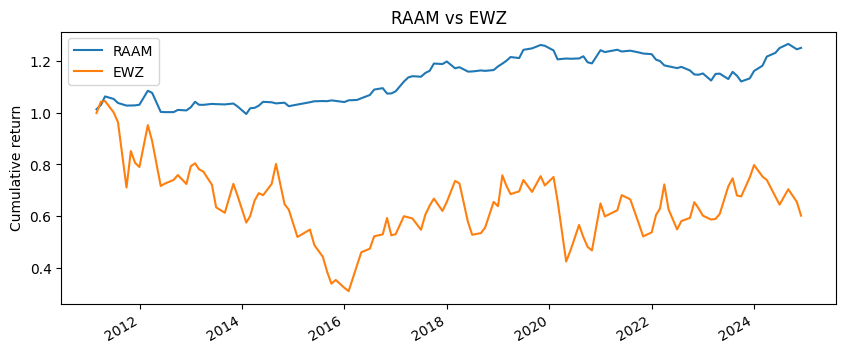

In [94]:
# Plot RAAM vs EWZ (monthly)
if len(cum) > 0:
    ax = cum.plot(label="RAAM", figsize=(10, 4))
    if "EWZ" in returns_df.columns:
        ewz_monthly = (1 + returns_df["EWZ"]).resample("ME").prod() - 1
        ewz_cum = (1 + ewz_monthly).cumprod()
        ewz_cum.reindex(cum.index).ffill().plot(ax=ax, label="EWZ")
    plt.legend()
    plt.title("RAAM vs EWZ" if "EWZ" in returns_df.columns else "RAAM cumulative return")
    plt.ylabel("Cumulative return")
    plt.show()

## Paper: Statistics and Figures

The cells below compute performance statistics, risk metrics, and publication-ready figures for the RAAM strategy vs benchmarks (e.g. EWZ). Run the backtest cell above first so `monthly_ret`, `cum`, and `returns_df` are defined.

In [95]:
# --- Performance statistics helpers (annualized, monthly data) ---
def ann_ret(monthly_series):
    """Annualized return from monthly returns."""
    if len(monthly_series.dropna()) == 0: return np.nan
    return (1 + monthly_series).prod() ** (12 / max(1, len(monthly_series.dropna()))) - 1

def ann_vol(monthly_series):
    """Annualized volatility (std * sqrt(12))."""
    return monthly_series.std() * np.sqrt(12) if monthly_series.std() == monthly_series.std() else np.nan

def sharpe(monthly_series, rf_monthly=0):
    """Sharpe ratio (annualized), assuming rf_monthly is monthly risk-free rate."""
    e = monthly_series.mean() - rf_monthly
    s = monthly_series.std()
    if s == 0 or np.isnan(s): return np.nan
    return (e / s) * np.sqrt(12)

def sortino(monthly_series, rf_monthly=0):
    """Sortino ratio (annualized): excess return / downside deviation."""
    excess = monthly_series - rf_monthly
    downside = excess[excess < 0].std()
    if downside == 0 or np.isnan(downside): return np.nan
    return (excess.mean() / downside) * np.sqrt(12)

def max_drawdown(cum_series):
    """Max drawdown (decimal)."""
    if len(cum_series) == 0: return np.nan
    rolling_max = cum_series.cummax()
    dd = (cum_series - rolling_max) / rolling_max
    return dd.min()

def calmar(monthly_series, cum_series, years=3):
    """Calmar ratio: annualized return / max drawdown (over full period)."""
    ann = ann_ret(monthly_series)
    md = max_drawdown(cum_series)
    if md >= 0 or np.isnan(md): return np.nan
    return ann / abs(md)

def drawdown_series(cum_series):
    """Drawdown series (decimal)."""
    rolling_max = cum_series.cummax()
    return (cum_series - rolling_max) / rolling_max

In [96]:
# --- Summary statistics table: RAAM vs benchmarks ---
benchmark_ticker = "EWZ"  # or "SPY" if in returns_df
rf_monthly = 0  # set to monthly risk-free rate if desired

strategies = {"RAAM": monthly_ret}
if benchmark_ticker in returns_df.columns:
    bench_monthly = (1 + returns_df[benchmark_ticker]).resample("ME").prod() - 1
    strategies[benchmark_ticker] = bench_monthly
# Align to common dates
common_idx = monthly_ret.dropna().index
for k in list(strategies.keys()):
    strategies[k] = strategies[k].reindex(common_idx).ffill().bfill()

rows = []
for name, ser in strategies.items():
    c = (1 + ser).cumprod()
    c = c.reindex(common_idx).ffill()
    rows.append({
        "Annualized Return": ann_ret(ser),
        "Annualized Volatility": ann_vol(ser),
        "Sharpe Ratio": sharpe(ser, rf_monthly),
        "Sortino Ratio": sortino(ser, rf_monthly),
        "Max Drawdown": max_drawdown(c),
        "Calmar Ratio": calmar(ser, c),
    })
summary_table = pd.DataFrame(rows, index=list(strategies.keys()))
summary_table.round(4)

,Annualized Return,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio
RAAM,0.0231,0.0525,0.4606,0.6113,-0.1120,0.2060
EWZ,-0.0517,0.3061,-0.0231,-0.0435,-0.5969,-0.0866


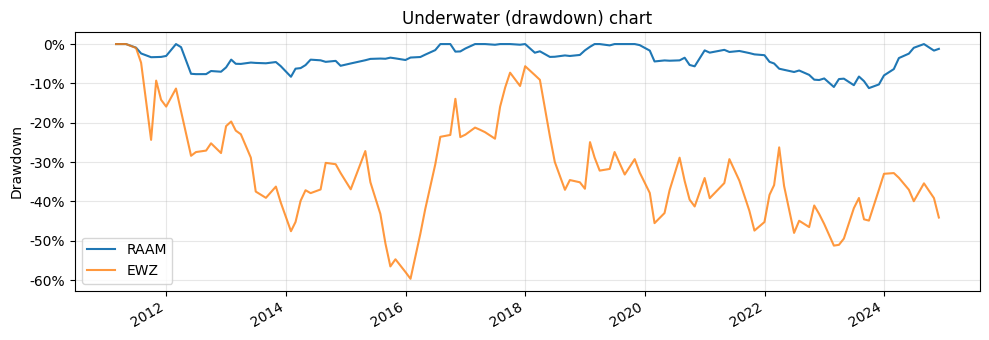

In [97]:
# --- Figure: Drawdown over time (RAAM vs benchmark) ---
fig, ax = plt.subplots(figsize=(10, 3.5))
dd_raam = drawdown_series(cum)
dd_raam.plot(ax=ax, label="RAAM", color="C0")
if benchmark_ticker in returns_df.columns:
    bench_cum = (1 + strategies[benchmark_ticker]).cumprod()
    dd_bench = drawdown_series(bench_cum.reindex(cum.index).ffill())
    dd_bench.plot(ax=ax, label=benchmark_ticker, color="C1", alpha=0.8)
ax.set_ylabel("Drawdown")
ax.set_title("Underwater (drawdown) chart")
ax.legend(loc="lower left")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

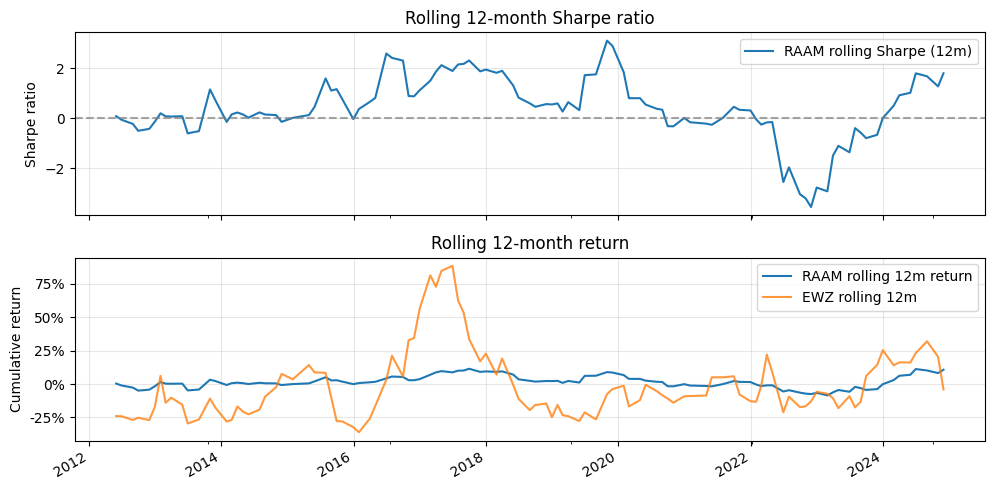

In [98]:
# --- Figure: Rolling 12-month Sharpe ratio and rolling 12-month return ---
roll_months = 12
roll_ret = monthly_ret.rolling(roll_months).apply(lambda x: (1 + x).prod() - 1)
roll_vol = monthly_ret.rolling(roll_months).std() * np.sqrt(12)
roll_sharpe = (monthly_ret.rolling(roll_months).mean() / monthly_ret.rolling(roll_months).std()) * np.sqrt(12)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
roll_sharpe.plot(ax=ax1, color="C0", label="RAAM rolling Sharpe (12m)")
ax1.axhline(0, color="gray", ls="--", alpha=0.7)
ax1.set_ylabel("Sharpe ratio")
ax1.set_title("Rolling 12-month Sharpe ratio")
ax1.legend()
ax1.grid(True, alpha=0.3)

roll_ret.plot(ax=ax2, color="C0", label="RAAM rolling 12m return")
if benchmark_ticker in returns_df.columns:
    bm = strategies[benchmark_ticker].reindex(monthly_ret.index).ffill()
    bm.rolling(roll_months).apply(lambda x: (1 + x).prod() - 1).plot(ax=ax2, label=f"{benchmark_ticker} rolling 12m", color="C1", alpha=0.8)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax2.set_ylabel("Cumulative return")
ax2.set_title("Rolling 12-month return")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

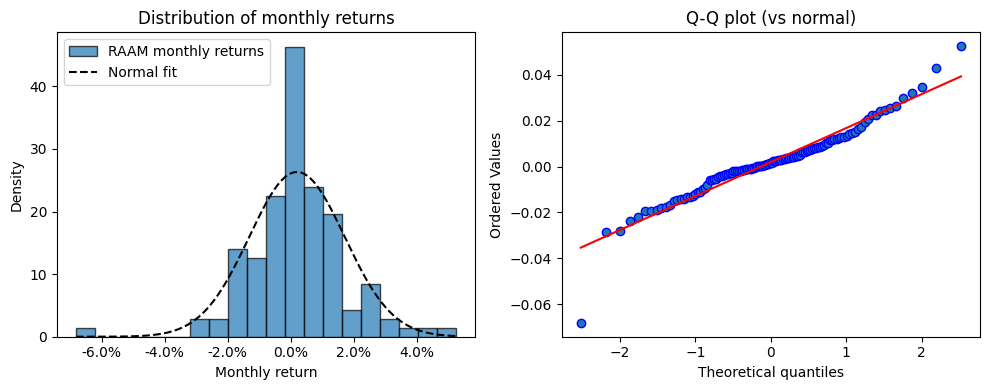

In [99]:
# --- Figure: Monthly return distribution and Q-Q plot ---
from scipy import stats as scipy_stats
r = monthly_ret.dropna()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.hist(r, bins=20, density=True, alpha=0.7, color="C0", edgecolor="black", label="RAAM monthly returns")
x = np.linspace(r.min(), r.max(), 200)
ax1.plot(x, scipy_stats.norm.pdf(x, r.mean(), r.std()), "k--", label="Normal fit")
ax1.set_xlabel("Monthly return")
ax1.set_ylabel("Density")
ax1.set_title("Distribution of monthly returns")
ax1.legend()
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))

scipy_stats.probplot(r, dist="norm", plot=ax2)
ax2.set_title("Q-Q plot (vs normal)")
ax2.get_lines()[0].set_markerfacecolor("C0")
plt.tight_layout()
plt.show()

Calendar-year returns (RAAM):
2011    0.031143
2012   -0.009822
2013    0.003196
2014    0.001097
2015    0.015592
2016    0.039940
2017    0.106753
2018   -0.015976
2019    0.067773
2020   -0.013499
2021   -0.012406
2022   -0.060877
2023    0.008441
2024    0.076947



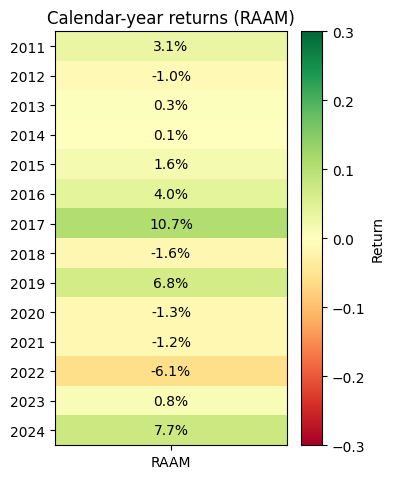

In [100]:
# --- Table & heatmap: Calendar-year returns ---
yr_returns = monthly_ret.groupby(monthly_ret.index.year).apply(lambda x: (1 + x).prod() - 1)
print("Calendar-year returns (RAAM):")
print(yr_returns.to_string())
print()

# Heatmap: years as rows, one column for RAAM
yr_df = pd.DataFrame({"RAAM": yr_returns})
fig, ax = plt.subplots(figsize=(4, max(4, len(yr_df) * 0.35)))
im = ax.imshow(yr_df.values, cmap="RdYlGn", aspect="auto", vmin=-0.3, vmax=0.3)
ax.set_xticks(range(yr_df.shape[1]))
ax.set_xticklabels(yr_df.columns)
ax.set_yticks(range(len(yr_df)))
ax.set_yticklabels(yr_df.index)
for i in range(len(yr_df)):
    for j in range(yr_df.shape[1]):
        ax.text(j, i, f"{yr_df.iloc[i, j]:.1%}", ha="center", va="center", fontsize=10)
plt.colorbar(im, ax=ax, label="Return")
ax.set_title("Calendar-year returns (RAAM)")
plt.tight_layout()
plt.show()

In [101]:
# --- Alpha, Beta, Information Ratio, Tracking error vs benchmark ---
if benchmark_ticker in returns_df.columns:
    raam = strategies["RAAM"].reindex(common_idx).dropna()
    bench = strategies[benchmark_ticker].reindex(common_idx).dropna()
    common = raam.index.intersection(bench.index)
    raam, bench = raam.loc[common], bench.loc[common]
    cov = np.cov(raam, bench)
    beta = cov[0, 1] / cov[1, 1] if cov[1, 1] != 0 else np.nan
    alpha = raam.mean() * 12 - beta * (bench.mean() * 12)  # annualized alpha (simplified)
    tracking_err = (raam - bench).std() * np.sqrt(12)
    ir = (raam.mean() - bench.mean()) / (raam - bench).std() * np.sqrt(12) if (raam - bench).std() > 0 else np.nan
    reg = np.polyfit(bench.values, raam.values, 1)
    alpha_reg = (raam.mean() - (reg[0] * bench.mean() + reg[1])) * 12
    print(f"vs {benchmark_ticker}:")
    print(f"  Beta (monthly):     {beta:.4f}")
    print(f"  Alpha (ann., from mean): {alpha:.4f}")
    print(f"  Alpha (ann., from regression): {alpha_reg:.4f}")
    print(f"  Tracking error (ann.): {tracking_err:.4f}")
    print(f"  Information ratio:  {ir:.4f}")

vs EWZ:
  Beta (monthly):     0.0539
  Alpha (ann., from mean): 0.0246
  Alpha (ann., from regression): -0.0000
  Tracking error (ann.): 0.2939
  Information ratio:  0.1064


In [102]:
# --- VaR and CVaR (Expected Shortfall) ---
r = monthly_ret.dropna()
q = [0.95, 0.99]
print("RAAM monthly returns — Risk metrics:")
for p in q:
    var = r.quantile(1 - p)
    cvar = r[r <= var].mean()
    print(f"  VaR({p*100:.0f}%):  {var:.4f}  |  CVaR({p*100:.0f}%):  {cvar:.4f}")
print(f"  Skewness: {r.skew():.4f}  |  Kurtosis: {r.kurtosis():.4f}")

RAAM monthly returns — Risk metrics:
  VaR(95%):  -0.0192  |  CVaR(95%):  -0.0317
  VaR(99%):  -0.0285  |  CVaR(99%):  -0.0484
  Skewness: -0.3459  |  Kurtosis: 4.1420


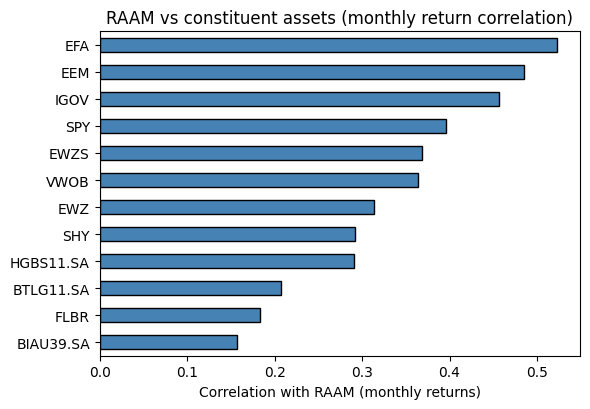

In [103]:
# --- Figure: Correlation of RAAM monthly returns with asset monthly returns ---
asset_monthly = returns_df.resample("ME").apply(lambda x: (1 + x).prod() - 1)
common_m = monthly_ret.dropna().index.intersection(asset_monthly.index)
raam_m = monthly_ret.reindex(common_m).ffill()
asset_m = asset_monthly.reindex(common_m).ffill()
corrs = asset_m.apply(lambda col: raam_m.corr(col))
corrs = corrs.sort_values()
fig, ax = plt.subplots(figsize=(6, max(4, len(corrs) * 0.35)))
corrs.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
ax.axvline(0, color="gray", ls="-")
ax.set_xlabel("Correlation with RAAM (monthly returns)")
ax.set_title("RAAM vs constituent assets (monthly return correlation)")
plt.tight_layout()
plt.show()

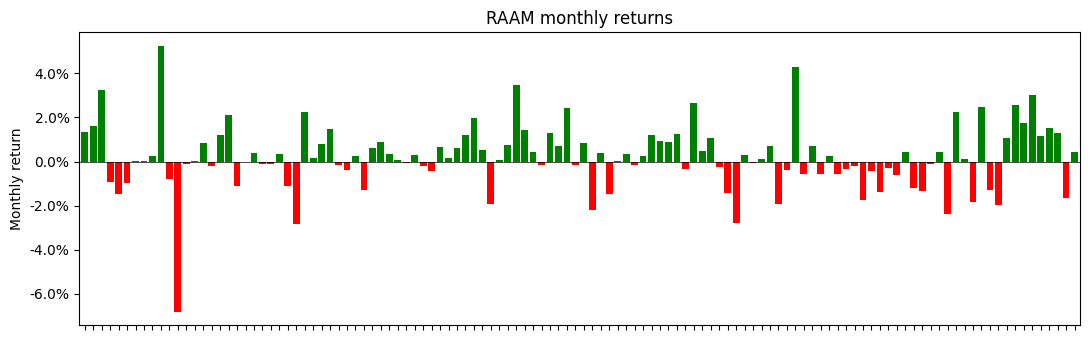

In [104]:
# --- Figure: Monthly returns (bar chart) ---
fig, ax = plt.subplots(figsize=(11, 3.5))
colors = ["green" if x >= 0 else "red" for x in monthly_ret.dropna()]
monthly_ret.dropna().plot(kind="bar", ax=ax, color=colors, width=0.8, edgecolor="none")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Monthly return")
ax.set_title("RAAM monthly returns")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: ""))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

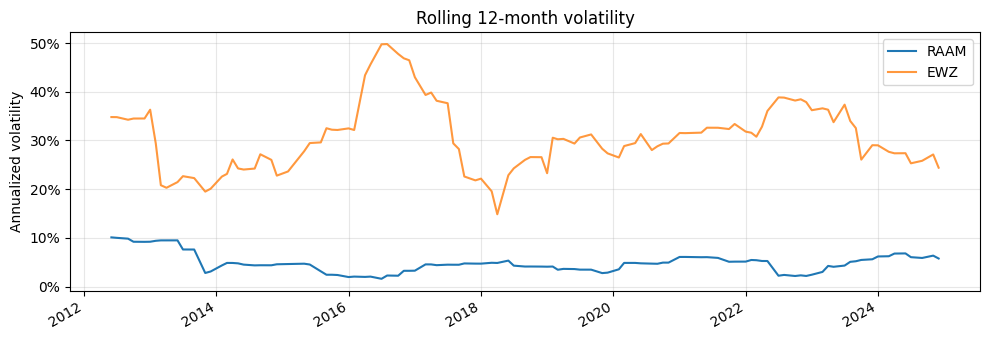

In [105]:
# --- Figure: Rolling 12-month volatility (RAAM vs benchmark) ---
roll_vol_raam = monthly_ret.rolling(12).std() * np.sqrt(12)
fig, ax = plt.subplots(figsize=(10, 3.5))
roll_vol_raam.plot(ax=ax, label="RAAM", color="C0")
if benchmark_ticker in returns_df.columns:
    bm = strategies[benchmark_ticker].reindex(monthly_ret.index).ffill()
    bm.rolling(12).std().multiply(np.sqrt(12)).plot(ax=ax, label=benchmark_ticker, color="C1", alpha=0.8)
ax.set_ylabel("Annualized volatility")
ax.set_title("Rolling 12-month volatility")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

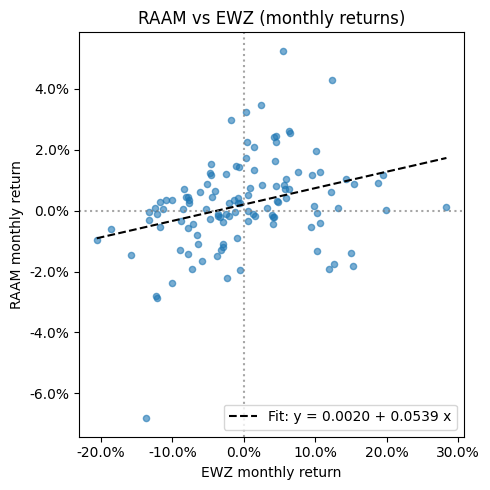

In [106]:
# --- Figure: RAAM vs benchmark scatter (monthly returns) and regression line ---
if benchmark_ticker in returns_df.columns:
    raam = strategies["RAAM"].reindex(common_idx).dropna()
    bench = strategies[benchmark_ticker].reindex(common_idx).dropna()
    common = raam.index.intersection(bench.index)
    x = bench.loc[common].values
    y = raam.loc[common].values
    b, a = np.polyfit(x, y, 1)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(x, y, alpha=0.6, s=20, color="C0")
    xx = np.linspace(x.min(), x.max(), 100)
    ax.plot(xx, a + b * xx, "k--", label=f"Fit: y = {a:.4f} + {b:.4f} x")
    ax.axhline(0, color="gray", ls=":", alpha=0.7)
    ax.axvline(0, color="gray", ls=":", alpha=0.7)
    ax.set_xlabel(f"{benchmark_ticker} monthly return")
    ax.set_ylabel("RAAM monthly return")
    ax.set_title(f"RAAM vs {benchmark_ticker} (monthly returns)")
    ax.legend()
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1%}"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1%}"))
    plt.tight_layout()
    plt.show()

In [107]:
# --- Additional statistics: win rate, best/worst month, consistency ---
r = monthly_ret.dropna()
yr_returns_raam = monthly_ret.groupby(monthly_ret.index.year).apply(lambda x: (1 + x).prod() - 1)
print("RAAM — Additional statistics:")
print(f"  Win rate (months positive): {(r > 0).mean():.1%}")
print(f"  Best month:  {r.max():.4f}  ({r.idxmax().strftime('%Y-%m')})")
print(f"  Worst month: {r.min():.4f}  ({r.idxmin().strftime('%Y-%m')})")
print(f"  % positive years: {(yr_returns_raam > 0).mean():.1%}")
print()
# Summary table in LaTeX (for paper)
print("Summary table (LaTeX-style):")
print(summary_table.to_latex(float_format="%.4f"))

RAAM — Additional statistics:
  Win rate (months positive): 57.6%
  Best month:  0.0526  (2012-02)
  Worst month: -0.0682  (2012-05)
  % positive years: 64.3%

Summary table (LaTeX-style):


ImportError: Missing optional dependency 'Jinja2'. DataFrame.style requires jinja2. Use pip or conda to install Jinja2.

TODO:
implement momentum
implement ATR trend / breakout system
implement average relative correlations